# Procesamiento de datos numéricos

Los modelos de ML trabajan con arreglos numéricos de Numpy, así que, sin importar su naturaleza, las variables de un conjunto de datos deben procesarse para generar características (**features**) numéricas.

Por esto, podría pensarse que sí una variable ya es numérica, no necesita procesamiento. Sin embargo, muchas veces si es necesario procesarlas, por diversas razones. Aquí vamos a ver algunas de las técnicas más utilizadas para procesar datos numéricos.

In [12]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "raw"
file_name = "adult.data"
file_path = DATA_DIR / file_name

In [13]:
import pandas as pd

df = pd.read_csv(
    file_path,
    header =None,
    names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
             'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
             'hours-per-week', 'native-country', 'income'],
    na_values= [' ?']
    )

df.dropna(inplace=True)

df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
24130,37,Private,199251,Some-college,10,Married-civ-spouse,Other-service,Wife,White,Female,0,0,40,United-States,<=50K
25036,65,Private,153522,HS-grad,9,Widowed,Other-service,Unmarried,White,Female,0,0,17,United-States,<=50K
18879,49,Private,291783,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
29487,74,Private,84197,Masters,14,Divorced,Sales,Not-in-family,White,Female,0,0,10,United-States,<=50K
17785,42,Private,403187,HS-grad,9,Divorced,Handlers-cleaners,Unmarried,Black,Female,0,0,40,United-States,<=50K


In [14]:
print(f'registros duplicados: {df.duplicated().sum()}')

registros duplicados: 23


In [15]:
df.drop_duplicates(inplace=True)
print(f'registros duplicados: {df.duplicated().sum()}')

registros duplicados: 0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education-num   30139 non-null  int64 
 5   marital-status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital-gain    30139 non-null  int64 
 11  capital-loss    30139 non-null  int64 
 12  hours-per-week  30139 non-null  int64 
 13  native-country  30139 non-null  object
 14  income          30139 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Antes de hacer cualquier procesamiento, es conveniente saber como se comportan o distribuyen los datos, usando los métodos `describe` e `hist`:

In [17]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,30139.000000,3.013900e+04,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,1.897950e+05,10.122532,1092.841202,88.439928,40.934703
std,13.131426,1.056586e+05,2.548738,7409.110596,404.445239,11.978753
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176275e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784170e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376045e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


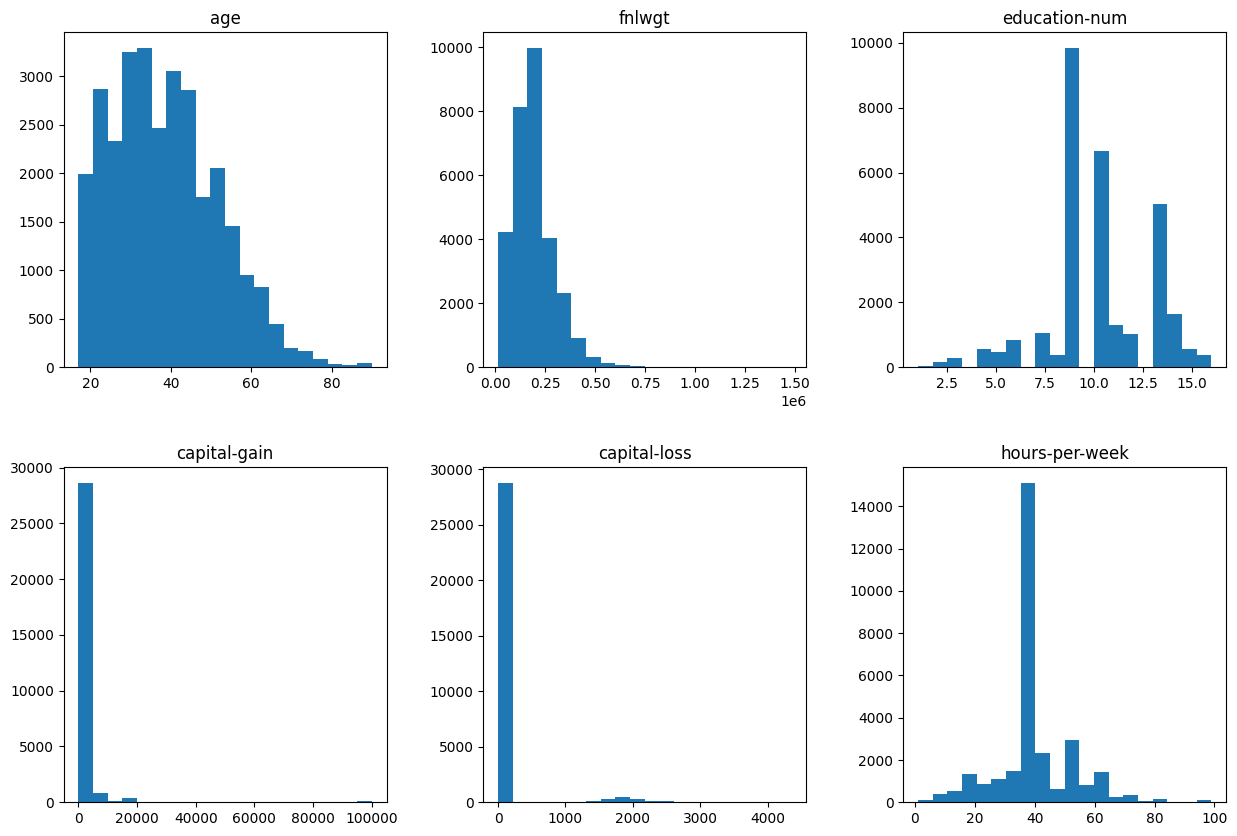

In [18]:
df.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(2,3));

Se observa que, en general, estás variables no cumplen con el supuesto de normalidad, aunque algunas (**age**, **hours-per-week**) se acercan a ser normales.

# Tratamiento de outliers

Los *outliers* son valores atípicos en la muestra. Los *outliers* causan problemas cuando se construyen modelos predictivos, tales como tiempos de entrenamiento más largos, pobre desempeño, e incremento en la varianza del modelo, por lo que es recomendable eliminarlos antes de construir los modelos.

Existen 2 tipos de *outliers*: los univariados que se pueden detectar viendo las distribuciones de los datos mediantes histogramas, o mediante diagramas de cajas y bigotes; y los multivariados, que solo se detectan analizando varias variables simultáneamente. Por ahora nos vamos a centrar en los *outliers* univariados.

Se puede observan que la gran mayoria de las observaciones están concentrados en los primeros bines, y que muy pocas observaciones están por fuera, por lo que se evidencia la existencia de *outliers*. Un diagrama de cajas y bigotes o [box plot](https://en.wikipedia.org/wiki/Box_plot) nos permitiría ver mejor la situación.

<Axes: >

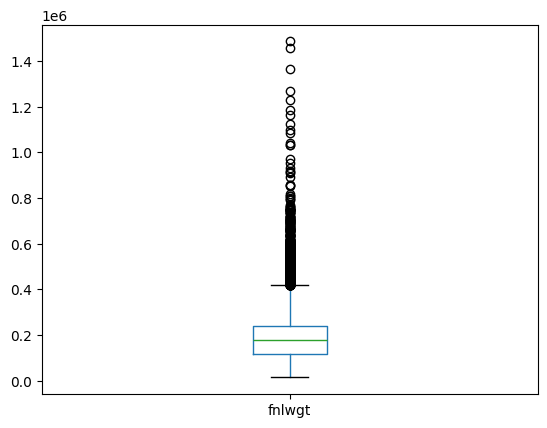

In [19]:
df.boxplot('fnlwgt', grid=False)

Una estrategia para intentar normalizar esta variable (esto se suele llammar **estandarizar**) sería eliminar los *outliers*. Existen 3 formas de hacerlo.

1.  Mediante el $Z-score$. En este método se asume que los datos tienen una distribución normal, y que los *outliers* están en las colas. Se calcula el $Z-score$ de cada observación mediante la fórmula:

$$Z = \frac{x - \mu}{\sigma},$$

y se eliminan las observaciones con $Z-scores$ mayor a cierto umbral, habitualmente 3.


In [20]:
print('Número de registros: ', df.shape[0])

Número de registros:  30139


In [21]:
df1 = df.copy()
#calculo de z-score
df1['z-score'] = (df1['fnlwgt'] - df1['fnlwgt'].mean())/df1['fnlwgt'].std()
#Filtrar, eliminando los registros que quedan a más de 3z de 0
df1 = df1[(df1['z-score']<=3)&((df1['z-score']>=-3))]
#Registros que quedan 
print('Número de registros: ', df1.shape[0])

Número de registros:  29817


2. Por percentiles: consiste en eliminar las observaciones que están más allá de ciertos percentiles, por ejemplo el 1 y el 99.

In [22]:
df2 = df.copy()
upper_limit = df2['fnlwgt'].quantile(.99) #percentil 99
lower_limit = df2['fnlwgt'].quantile(.01) #percentil 1
df2 = df2[(df2['fnlwgt'] < upper_limit) & (df2['fnlwgt'] > lower_limit)]
print('Número de registros: ', df2.shape[0])

Número de registros:  29535


3. Basado en rango intercuartil IQR: En este método se eliminan los *outliers* marcados en el boxplot que están más allá de los siguientes límites:
$$ upper\_limit = Q3 + 1.5*IQR$$
$$ lower\_limit = Q1 - 1.5*IQR$$

Donde:
$$IQR = Q3 - Q1$$

In [23]:
df3 = df.copy()
Q1 = df3['fnlwgt'].quantile(0.25)
Q3 = df3['fnlwgt'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR
df3 = df3[(df3['fnlwgt'] < upper_limit)& (df3['fnlwgt'] > lower_limit)]
print('Número de registros: ', df3.shape[0])

Número de registros:  29235


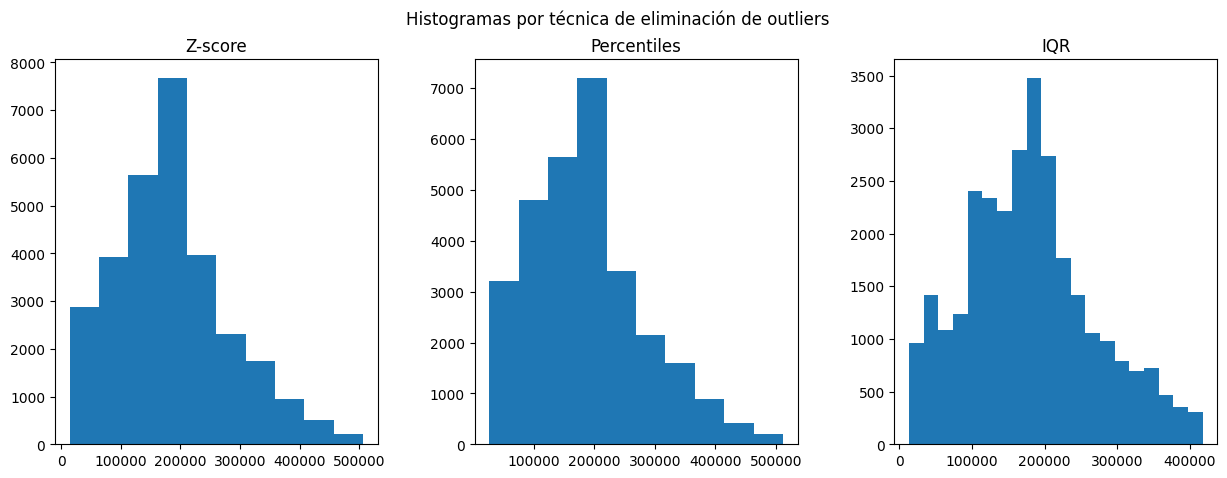

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15,5)
    )
fig.suptitle('Histogramas por técnica de eliminación de outliers')
df1.hist('fnlwgt', grid=False, ax=ax[0])
ax[0].title.set_text('Z-score')
df2.hist('fnlwgt', grid=False, ax=ax[1])
ax[1].title.set_text('Percentiles')
df3.hist('fnlwgt', bins=20, grid=False, ax=ax[2])
ax[2].title.set_text('IQR')

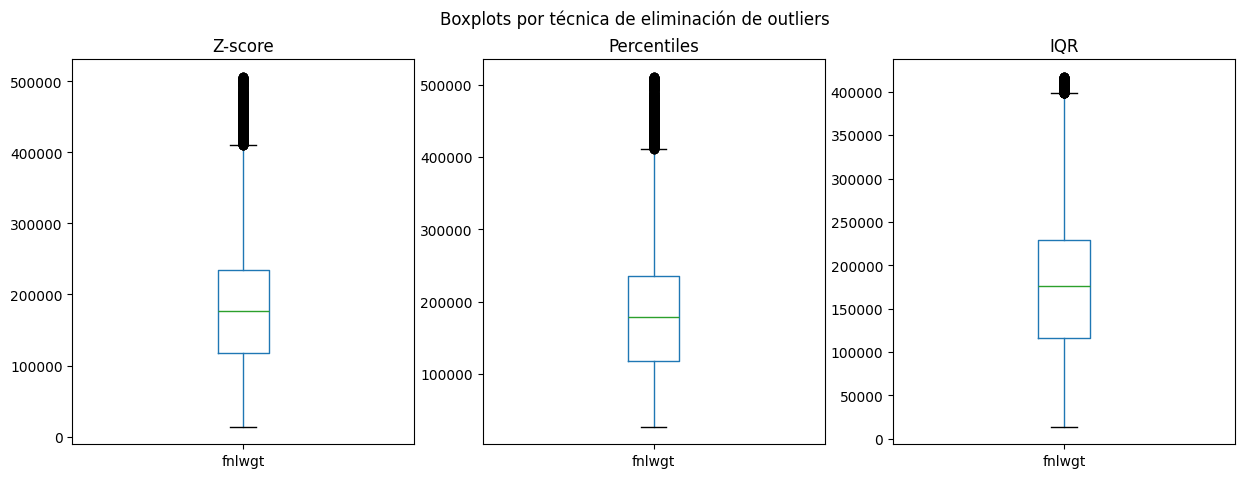

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15,5)
    )
fig.suptitle('Boxplots por técnica de eliminación de outliers')
df1.boxplot('fnlwgt', grid=False, ax=ax[0])
ax[0].title.set_text('Z-score')
df2.boxplot('fnlwgt', grid=False, ax=ax[1])
ax[1].title.set_text('Percentiles')
df3.boxplot('fnlwgt', grid=False, ax=ax[2])
ax[2].title.set_text('IQR')

In [26]:
df1_desc = df1.fnlwgt.describe()
df2_desc = df2.fnlwgt.describe()
df3_desc = df3.fnlwgt.describe()

df_desc = pd.concat([df1_desc, df2_desc, df3_desc], axis=1)
df_desc

,fnlwgt,fnlwgt,fnlwgt
count,29817.000000,29535.000000,29235.000000
mean,185067.523158,186935.158524,179757.088182
std,94578.974461,93981.282224,87556.091118
min,13769.000000,27162.000000,13769.000000
25%,117217.000000,118612.000000,116138.000000
50%,177420.000000,178417.000000,175958.000000
75%,234665.000000,235848.000000,229180.000000
max,506436.000000,511068.000000,417419.000000


Los 2 últimos métodos son más robustos, porque no asumen que la distribución de los datos es normal,pero suelen descartar más registros.

# Normalización

Algunos modelos de ML funcionan mejor si todas las características o *features* tienen rangos similares. El proceso de transformar los datos para que queden en un rango específico, usualmente $[0,1]$ o $[-1,1]$, se conoce como **normalización**.

La manera más simple de hacer esto es restando a cada registro el valor mínimo que toma la variable, y dividir este resultado entre la resta del valor mínimo y el valor máximo.

$\frac{X-xmin}{xmax-xmin}$

In [27]:
df['hours-per-week-scaled']= (df['hours-per-week'] - df['hours-per-week'].min()) / (df['hours-per-week'].max() - df['hours-per-week'].min())
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,hours-per-week-scaled
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0.397959
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0.122449
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0.397959
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0.397959
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0.397959


array([[<Axes: title={'center': 'hours-per-week'}>,
        <Axes: title={'center': 'hours-per-week-scaled'}>]], dtype=object)

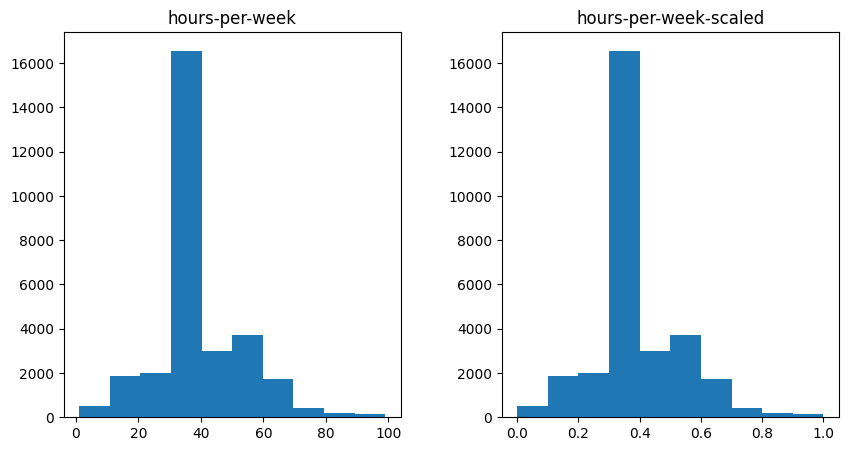

In [28]:
df[['hours-per-week','hours-per-week-scaled']].hist(figsize=(10,5), grid=False)

In [29]:
df['hours-per-week-scaled'].describe()

count    30139.000000
mean         0.407497
std          0.122232
min          0.000000
25%          0.397959
50%          0.397959
75%          0.448980
max          1.000000
Name: hours-per-week-scaled, dtype: float64

Esto también se puede hacer con el método `MinMaxScaler` de `Scikit Learn`:

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = df[['hours-per-week']]
df['hours-per-week-scaled'] = scaler.fit_transform(X)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,hours-per-week-scaled
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0.397959
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0.122449
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0.397959
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0.397959
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0.397959


array([[<Axes: title={'center': 'hours-per-week'}>,
        <Axes: title={'center': 'hours-per-week-scaled'}>]], dtype=object)

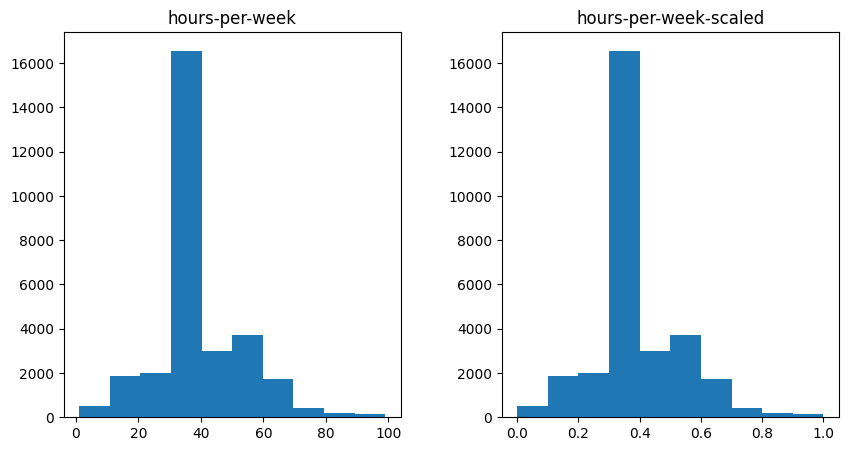

In [31]:
df[['hours-per-week','hours-per-week-scaled']].hist(figsize=(10,5), grid=False)

In [32]:
df['hours-per-week-scaled'].describe()

count    30139.000000
mean         0.407497
std          0.122232
min          0.000000
25%          0.397959
50%          0.397959
75%          0.448980
max          1.000000
Name: hours-per-week-scaled, dtype: float64

No se recomienda usar `MinMaxScaler` con variables **sparse**, es decir variables que tienen muchos valores 0. En este caso se recomienda normalizar dividiendo cada valor de la  variable por el valor absoluto máximo que toma esta. Esto se puede hacer con el método `MaxAbsScaler`.

In [33]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X = df[['capital-loss']]
df['capital-loss-scaled'] = scaler.fit_transform(X)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,hours-per-week-scaled,capital-loss-scaled
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0.397959,0.0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0.122449,0.0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0.397959,0.0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0.397959,0.0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0.397959,0.0


array([[<Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'capital-loss-scaled'}>]], dtype=object)

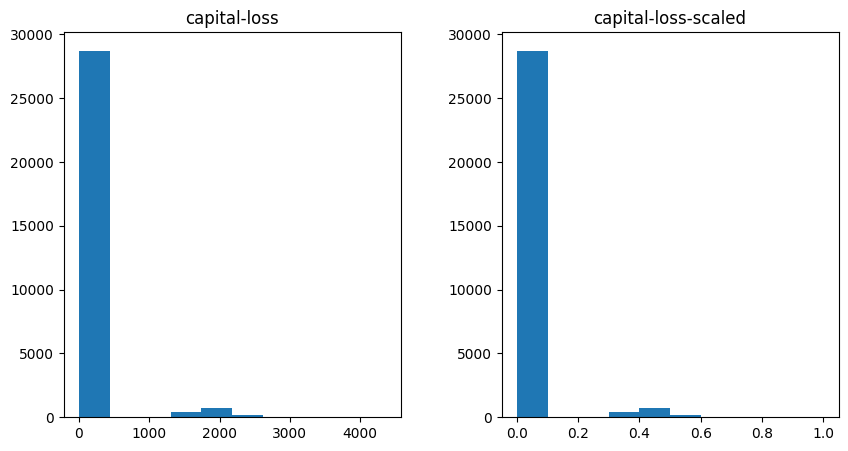

In [34]:
df[['capital-loss','capital-loss-scaled']].hist(figsize=(10,5), grid=False)

In [35]:
df['capital-loss-scaled'].describe()

count    30139.000000
mean         0.020303
std          0.092848
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: capital-loss-scaled, dtype: float64

Ninguno de estos 2 métodos modifica la distribución de los datos. No son recomendados cuando la variable a normalizar tiene **outliers** o su rango es muy amplio, pero la mayoría de valores están concentrados en un rango más pequeño.

# Estandarización

En algunos casos, dependiendo del modelo y de los datos, se prefiere **centrar** la distribución de la variable, para que tenga **media 0 y varianza 1**.

La forma más simple de conseguir esto consiste en restarle a cada valor de la variable la media y dividirla por la desviación estándar. En `Scikit-Learn`, el método `StandardScaler` hace esto:

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'age-scaled'}>]], dtype=object)

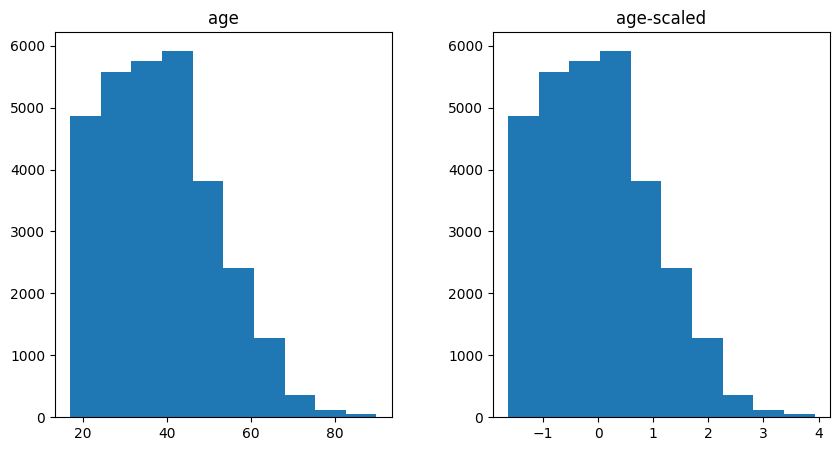

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df[['age']]
df['age-scaled'] = scaler.fit_transform(X)
df[['age','age-scaled']].hist(figsize=(10,5), grid=False)

In [37]:
df[['age','age-scaled']].describe()

,age,age-scaled
count,30139.000000,3.013900e+04
mean,38.441720,5.941032e-17
std,13.131426,1.000017e+00
min,17.000000,-1.632883e+00
25%,28.000000,-7.951835e-01
50%,37.000000,-1.097934e-01
75%,47.000000,6.517511e-01
max,90.000000,3.926393e+00


Si la variable tiene *outliers*, y no se quieren eliminar, puede estandarizarse de manera robusta, con el método `RobustScaler`, que elimina la mediana y escala los datos según el RIQ.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'age-scaled'}>,
        <Axes: title={'center': 'age-robust-scaled'}>]], dtype=object)

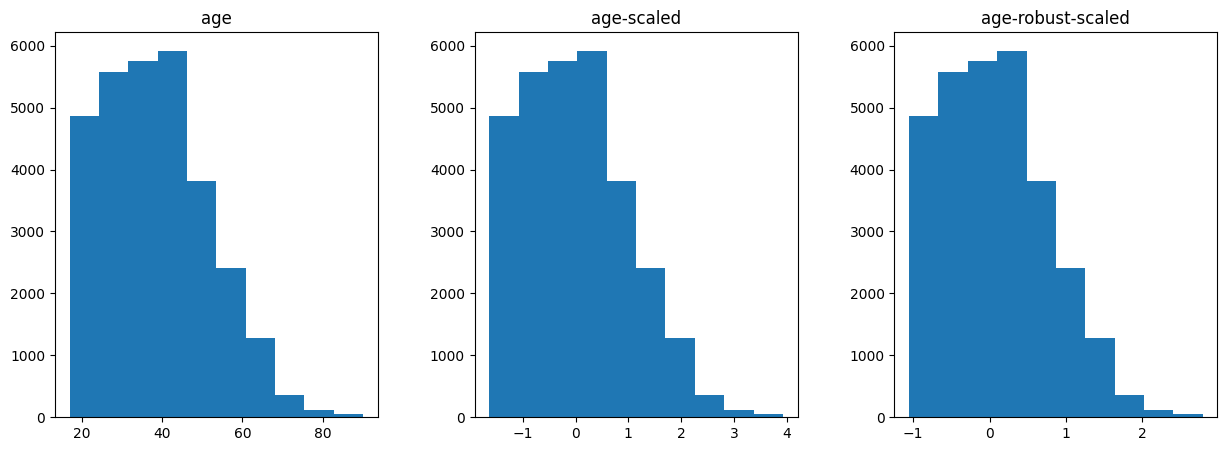

In [38]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['age-robust-scaled'] = scaler.fit_transform(X)
df[['age','age-scaled', 'age-robust-scaled']].hist(figsize=(15,5), grid=False, layout=(1,3))

In [39]:
df[['age','age-scaled', 'age-robust-scaled']].describe()

,age,age-scaled,age-robust-scaled
count,30139.000000,3.013900e+04,30139.000000
mean,38.441720,5.941032e-17,0.075880
std,13.131426,1.000017e+00,0.691128
min,17.000000,-1.632883e+00,-1.052632
25%,28.000000,-7.951835e-01,-0.473684
50%,37.000000,-1.097934e-01,0.000000
75%,47.000000,6.517511e-01,0.526316
max,90.000000,3.926393e+00,2.789474


# Transformaciones de formas de distribución

Algunos modelos de ML, particularmente los lineales, requieren que las variables tengan una distribución normal, esto es, que **cumplan con el supuesto de normalidad**. En este caso, es necesario usar métodos que **corrijan** la distribución de la variable.

Con variables que tienen distribución exponencial podría *escalizarse* aplicando primero la función logaritmo y luego usar `StandardScaler` para estandarizar, aunque esto no funciona si la variable tiene valores negativos.

array([[<Axes: title={'center': 'fnlwgt'}>,
        <Axes: title={'center': 'fnlwgt-log'}>,
        <Axes: title={'center': 'fnlwgt-log-scaled'}>]], dtype=object)

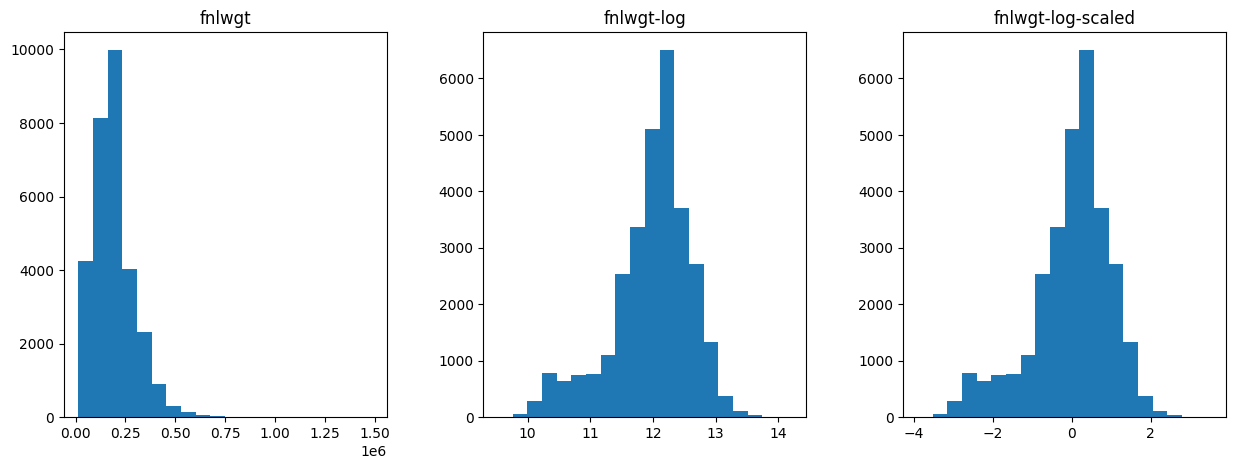

In [40]:
import numpy as np

scaler = StandardScaler()
df['fnlwgt-log'] = np.log1p(df['fnlwgt'])
df['fnlwgt-log-scaled'] = scaler.fit_transform(df[['fnlwgt-log']])
df[['fnlwgt','fnlwgt-log', 'fnlwgt-log-scaled']].hist(bins=20, figsize=(15, 5), layout=(1,3), grid=False)

In [41]:
df[['fnlwgt','fnlwgt-log', 'fnlwgt-log-scaled']].describe()

,fnlwgt,fnlwgt-log,fnlwgt-log-scaled
count,3.013900e+04,30139.000000,3.013900e+04
mean,1.897950e+05,11.983801,1.360779e-15
std,1.056586e+05,0.630616,1.000017e+00
min,1.376900e+04,9.530248,-3.890789e+00
25%,1.176275e+05,11.675287,-4.892352e-01
50%,1.784170e+05,12.091884,1.713961e-01
75%,2.376045e+05,12.378367,6.256938e-01
max,1.484705e+06,14.210727,3.531409e+00


Una generalización de este método son las [transformaciones de potencias](https://en.wikipedia.org/wiki/Power_transform), que son métodos no lineales de mapeo. Para hacer esto se puede usar `PowerTransformer` de `Scikit Learn`.

array([[<Axes: title={'center': 'fnlwgt'}>,
        <Axes: title={'center': 'fnlwgt-log-scaled'}>,
        <Axes: title={'center': 'fnlwgt-pt'}>]], dtype=object)

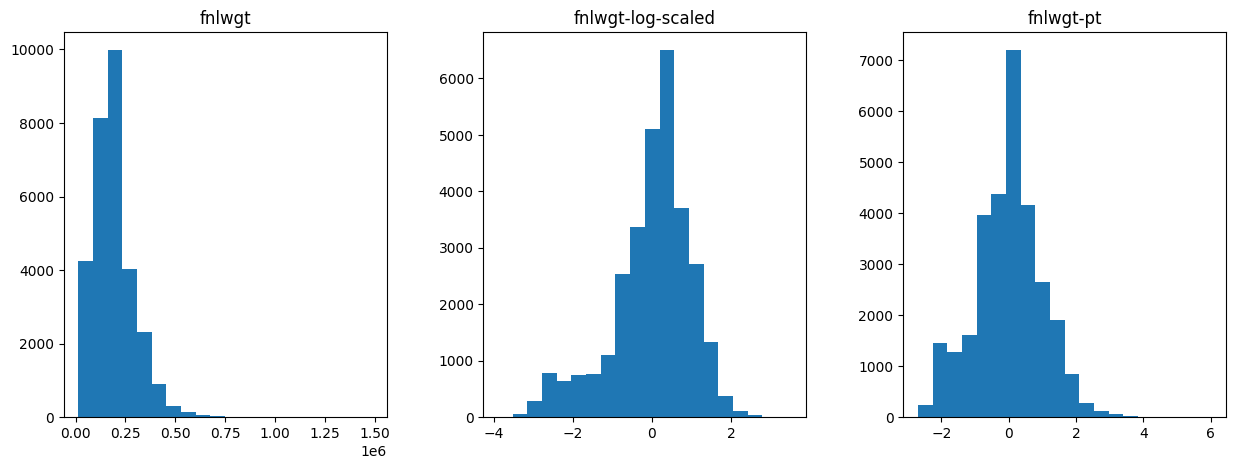

In [42]:
from sklearn.preprocessing import PowerTransformer

scaler = PowerTransformer()
df['fnlwgt-pt'] = scaler.fit_transform(df[['fnlwgt']])
df[['fnlwgt','fnlwgt-log-scaled', 'fnlwgt-pt']].hist(bins=20, figsize=(15,5), grid=False, layout=(1,3))

In [43]:
df[['fnlwgt','fnlwgt-log-scaled', 'fnlwgt-pt']].describe()

,fnlwgt,fnlwgt-log-scaled,fnlwgt-pt
count,3.013900e+04,3.013900e+04,3.013900e+04
mean,1.897950e+05,1.360779e-15,2.876214e-16
std,1.056586e+05,1.000017e+00,1.000017e+00
min,1.376900e+04,-3.890789e+00,-2.702129e+00
25%,1.176275e+05,-4.892352e-01,-6.165679e-01
50%,1.784170e+05,1.713961e-01,5.341747e-02
75%,2.376045e+05,6.256938e-01,5.867021e-01
max,1.484705e+06,3.531409e+00,6.024798e+00


Variables muy sesgadas o con distribuciones no exponenciales no se pueden transformar de ninguna manera:

array([[<Axes: title={'center': 'capital-gain'}>,
        <Axes: title={'center': 'capital-gain-pt'}>]], dtype=object)

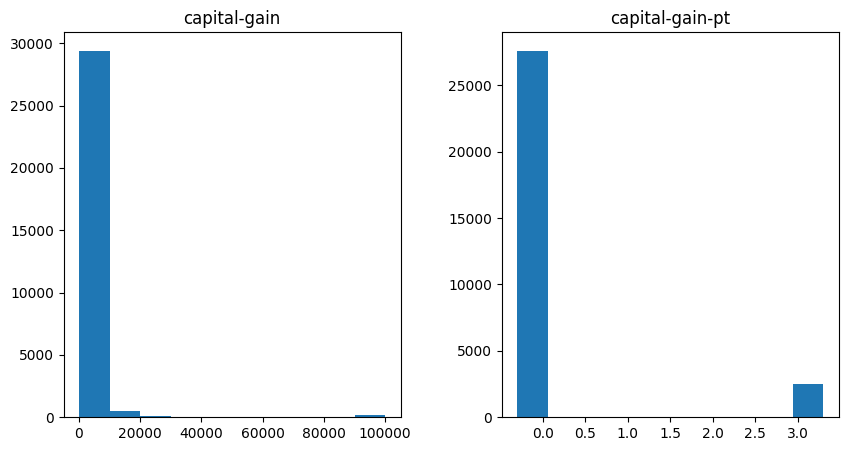

In [44]:
df['capital-gain-pt'] = scaler.fit_transform(df[['capital-gain']])
df[['capital-gain','capital-gain-pt']].hist(figsize=(10,5), grid=False)

# Binning

**Binning** —también llamado *discretización*— es una técnica que convierte una variable numérica continua en una variable **discreta** formada por **intervalos (bins)**.

En otras palabras “Agrupa los valores continuos en contenedores o categorías que representan rangos de valores.”

En `Scikit‑learn`, el método estándar para hacerlo es **`KBinsDiscretizer`**, que permite dividir una variable en un número definido de intervalos.

El binning es útil cuando:

*   Un modelo se beneficia al trabajar con categorías en lugar de valores continuos.
*   Se desea **reducir el efecto del ruido** en variables con alta variabilidad.
*   Se quiere **simplificar** la relación entre una variable y la respuesta (por ejemplo, curvas no lineales).
*   Se buscan **modelos interpretables**, como reglas de decisión o análisis segmentados.
*   Se pretende facilitar la **visualización**.

**Estrategia de partición**: `KBinsDiscretizer` permite tres estrategias principales:

1. “uniform”: Divide el rango de valores en intervalos del **mismo tamaño**. Ejemplo: Si la variable va de 0 a 100 y se eligen 5 bins → cada uno tendrá ancho 20.

2. “quantile”: Ajusta los bins para que cada uno tenga **aproximadamente el mismo número de observaciones**. En datos sesgados, permite bins más estrechos donde hay más densidad.

3. “kmeans”: Usa K‑means para agrupar los valores de forma que cada cluster represente un bin. Es útil cuando los datos no están uniformemente distribuidos.

**¿Qué devuelve el binning en scikit‑learn?**

`KBinsDiscretizer` puede devolver los bins en tres formatos (`encode=`)
*   **"ordinal"** → un número entero por bin (0, 1, 2, …).
*   **"onehot"** → codificación one‑hot (una columna por bin).
*   **"onehot-dense"** → similar al anterior, pero en matriz densa.

In [45]:
from sklearn.preprocessing import KBinsDiscretizer

kbin = KBinsDiscretizer(
    n_bins=3,
    strategy='uniform',
    encode='ordinal'
    )

kbin.fit(df[['age']])
kbin.bin_edges_

array([array([17.        , 41.33333333, 65.66666667, 90.        ])],
      dtype=object)

In [46]:
df['age-binned'] = kbin.transform(df[['age']])
df[['age','age-binned']].sample(5)

,age,age-binned
29521,25,0.0
12238,40,0.0
1111,33,0.0
15959,67,2.0
25648,32,0.0


In [47]:
df['age-binned'].value_counts()

age-binned
0.0    18513
1.0    10788
2.0      838
Name: count, dtype: int64

In [48]:
kbin = KBinsDiscretizer(
    n_bins=3,
    strategy='quantile',
    encode='ordinal'
    )

kbin.fit(df[['age']])
kbin.bin_edges_

c:\Users\saram\repos\ap-2026-1-62\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([array([17., 31., 44., 90.])], dtype=object)

In [49]:
df['age-binned'] = kbin.transform(df[['age']])
df[['age','age-binned']].sample(5)

,age,age-binned
25089,39,1.0
17583,49,2.0
1289,50,2.0
5597,26,0.0
23474,55,2.0


In [50]:
df['age-binned'].value_counts()

age-binned
1.0    10412
2.0    10143
0.0     9584
Name: count, dtype: int64

In [51]:
kbin = KBinsDiscretizer(
    n_bins=3,
    strategy='kmeans',
    encode='ordinal')

kbin.fit(df[['age']])
kbin.bin_edges_

array([array([17.        , 34.14395474, 50.34232346, 90.        ])],
      dtype=object)

In [52]:
df['age-binned'] = kbin.transform(df[['age']])
df[['age','age-binned']].sample(5)

,age,age-binned
16073,34,0.0
30562,43,1.0
27925,68,2.0
6222,54,2.0
17595,33,0.0


In [53]:
df['age-binned'].value_counts()

age-binned
0.0    12897
1.0    11551
2.0     5691
Name: count, dtype: int64

# Tarea

1. Haga tratamiento de *outliers* a la variable **age** por los 3 métodos descritos, y compare los resultados. ¿Con cúal método se quedaría?

2. Ahora *normalice* la variable **age** de 3 maneras:
- Sin eliminar *outliers*, usando `MinMaxScaler()`
- Sin eliminar *outliers*, usando `RobustScaler()`.
- Eliminando *outliers* previamente por el método preferido, y luego usando `MinMaxScaler()`.

Compare los resultados.

3. Ahora haga lo siguiente para *estandarizar* la variable **age**:
- Aplique logaritmo a la variable **age**.
- Haga transformación de potencia a la variable **age**.

Compare los resultados. ¿Cúal de los 2 da una distribución más cercana a la normal?